In [1]:
import pandas as pd
import numpy as np
import math

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier


In [2]:
df = pd.read_csv('final_merged_olist_with_geolocationV4.csv')


In [3]:
df.head()

,total_spent,shipping_fee,avg_review,unique_categories,total_items,delivery_time_days,customer_state,repeat_buyer
0,141.90,12.00,5.0,1,1,6.0,SP,0
1,27.19,8.29,4.0,1,1,3.0,SP,0
2,86.22,17.22,3.0,1,1,25.0,SC,0
3,43.62,17.63,4.0,1,1,20.0,PA,0
4,196.89,16.89,5.0,1,1,13.0,SP,0


In [4]:
df.columns

Index(['total_spent', 'shipping_fee', 'avg_review', 'unique_categories',
       'total_items', 'delivery_time_days', 'customer_state', 'repeat_buyer'],
      dtype='object')

In [5]:
df['repeat_buyer'].value_counts()

,count
repeat_buyer,
0,89988
1,2764


In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode categorical columns
le = LabelEncoder()
df["customer_state"] = le.fit_transform(df["customer_state"])

# Features and labels
X = df.drop(columns=["repeat_buyer"])
y = df["repeat_buyer"]



In [7]:
X.columns

Index(['total_spent', 'shipping_fee', 'avg_review', 'unique_categories',
       'total_items', 'delivery_time_days', 'customer_state'],
      dtype='object')

### random forest ###

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42,stratify=y)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     26997
           1       0.86      0.55      0.67       829

    accuracy                           0.98     27826
   macro avg       0.92      0.78      0.83     27826
weighted avg       0.98      0.98      0.98     27826

Accuracy: 0.984043700136563


In [9]:
def measure_error(y_true, y_pred, label):
    return pd.Series({
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred)
    }, name=label)

# Usage example
error_report = measure_error(y_test, y_pred, 'RandomForest')
print(error_report)


accuracy     0.984044
precision    0.859813
recall       0.554885
f1           0.674487
Name: RandomForest, dtype: float64


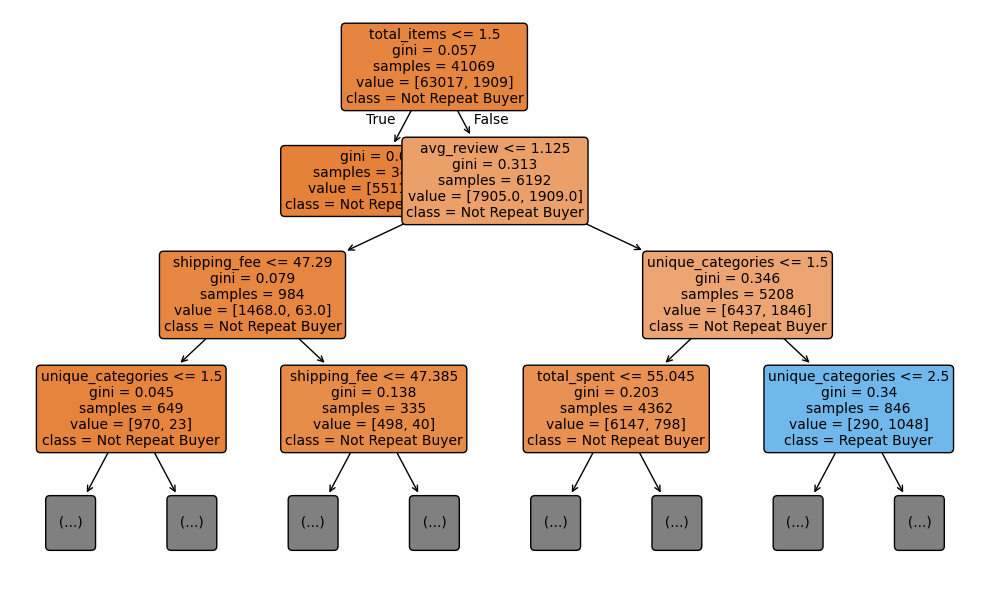

In [10]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Choose one tree from the forest
tree_estimator = rf.estimators_[0]

# Plot a simplified version
plt.figure(figsize=(10, 6))  # adjust as needed
plot_tree(
    tree_estimator,
    max_depth=3,  # LIMIT the depth shown here
    filled=True,
    feature_names=X.columns,
    class_names=["Not Repeat Buyer", "Repeat Buyer"],
    rounded=True,
    fontsize=10
)
plt.tight_layout()
plt.show()


[Text(0, 0.5, 'Relative Importance')]

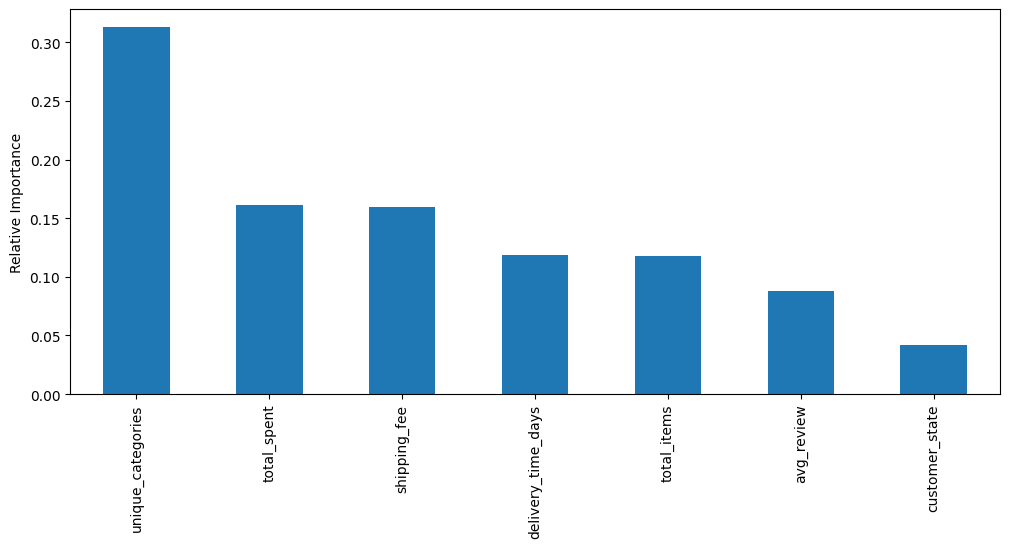

In [11]:
def measure_error(y_true, y_pred, label):
    return pd.Series({'accuracy':accuracy_score(y_true, y_pred),
                      'precision': precision_score(y_true, y_pred),
                      'recall': recall_score(y_true, y_pred),
                      'f1': f1_score(y_true, y_pred)},
                      name=label)
feature_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
fig = plt.figure(figsize=(12,5))
ax = feature_imp.plot(kind='bar')
ax.set(ylabel='Relative Importance')

In [12]:
# Make predictions
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# Combine error metrics
train_test_full_error = pd.concat([
    measure_error(y_train, y_train_pred, 'train'),
    measure_error(y_test, y_test_pred, 'test')
], axis=1)

# Display results
train_test_full_error


,train,test
accuracy,0.999985,0.984044
precision,1.000000,0.859813
recall,0.999483,0.554885
f1,0.999742,0.674487


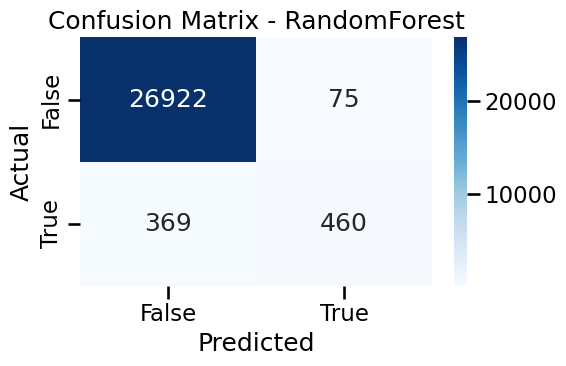

In [13]:


# Confusion matrix for the new model
mat = confusion_matrix(y_test, y_test_pred)

# Plot
sns.set_context('talk')
plt.figure(figsize=(6, 4))  # Optional: adjust figure size
ax = sns.heatmap(mat, annot=True, fmt='d', cmap='Blues')
labels = ['False', 'True']
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.title('Confusion Matrix - RandomForest')
plt.tight_layout()
plt.show()


In [14]:
par_used= rf.get_params()
par_used

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [15]:
# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [15, 20, 25],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [5, 10, 15],
    'bootstrap': [True]
}

# GridSearchCV object
best_rf = GridSearchCV(
    RandomForestClassifier(random_state=42,n_jobs=-1),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit the model
best_rf.fit(X_train, y_train)

# Show best parameters
print("Best Parameters:", best_rf.best_params_)
print("Best F1 Score :", best_rf.best_score_)


Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters: {'bootstrap': True, 'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best F1 Score : 0.6625199032545244


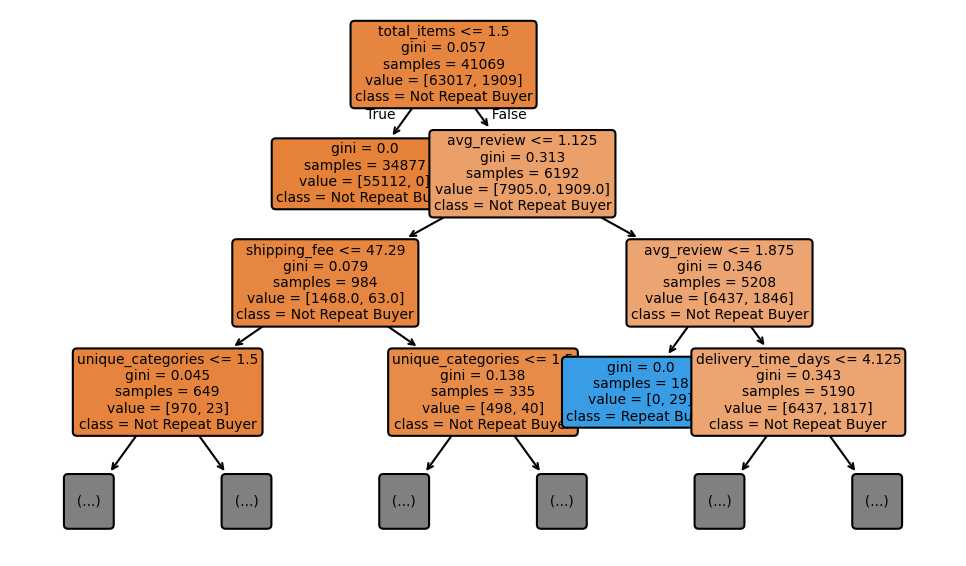

In [16]:

best_model = best_rf.best_estimator_
# Choose one tree from the forest
tree_estimator = best_model.estimators_[0]

# Plot a simplified version
plt.figure(figsize=(10, 6))  # adjust as needed
plot_tree(
    tree_estimator,
    max_depth=3,  # LIMIT the depth shown here
    filled=True,
    feature_names=X.columns,
    class_names=["Not Repeat Buyer", "Repeat Buyer"],
    rounded=True,
    fontsize=10
)
plt.tight_layout()
plt.show()


In [17]:
# Make predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Combine error metrics
train_test_full_error = pd.concat([
    measure_error(y_train, y_train_pred, 'train'),
    measure_error(y_test, y_test_pred, 'test')
], axis=1)

# Display results
train_test_full_error


,train,test
accuracy,0.986662,0.983612
precision,0.904006,0.862136
recall,0.618088,0.535585
f1,0.734193,0.660714


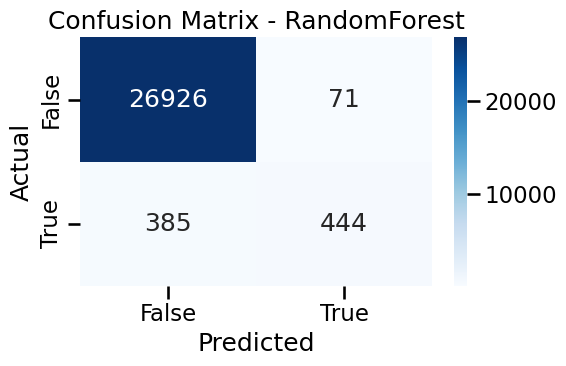

In [18]:
# Confusion matrix for the new model
mat = confusion_matrix(y_test, y_test_pred)

# Plot
sns.set_context('talk')
plt.figure(figsize=(6, 4))  # Optional: adjust figure size
ax = sns.heatmap(mat, annot=True, fmt='d', cmap='Blues')
labels = ['False', 'True']
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.title('Confusion Matrix - RandomForest')
plt.tight_layout()
plt.show()


In [19]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     26997
           1       0.86      0.54      0.66       829

    accuracy                           0.98     27826
   macro avg       0.92      0.77      0.83     27826
weighted avg       0.98      0.98      0.98     27826



In [20]:
from sklearn.metrics import precision_recall_curve

# ──> get the probability of “repeat buyer” (class 1), not the 0/1 prediction
y_scores = best_model.predict_proba(X_test)[:, 1]

# now compute the full precision/recall arrays
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)


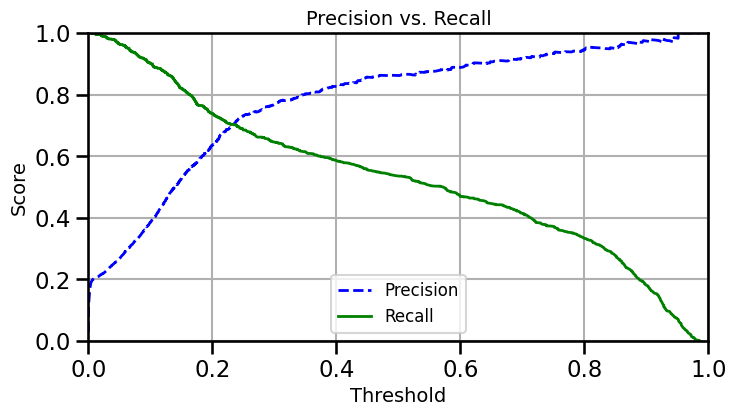

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve


y_scores = best_model.predict_proba(X_test)[:, 1]

# 3) Compute precision, recall, thresholds  (shape: len(thresholds)+1)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

p = precisions[:-1]
r = recalls[:-1]
t = thresholds

# 5) Plot both curves on the same axes:
plt.figure(figsize=(8, 4))
plt.plot(t, p, "b--", label="Precision", linewidth=2)
plt.plot(t, r, "g-",  label="Recall",    linewidth=2)

plt.xlabel("Threshold", fontsize=14)
plt.ylabel("Score",     fontsize=14)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.grid(True)
plt.legend(loc="lower center", fontsize=12)
plt.title("Precision vs. Recall", fontsize=14)
plt.show()


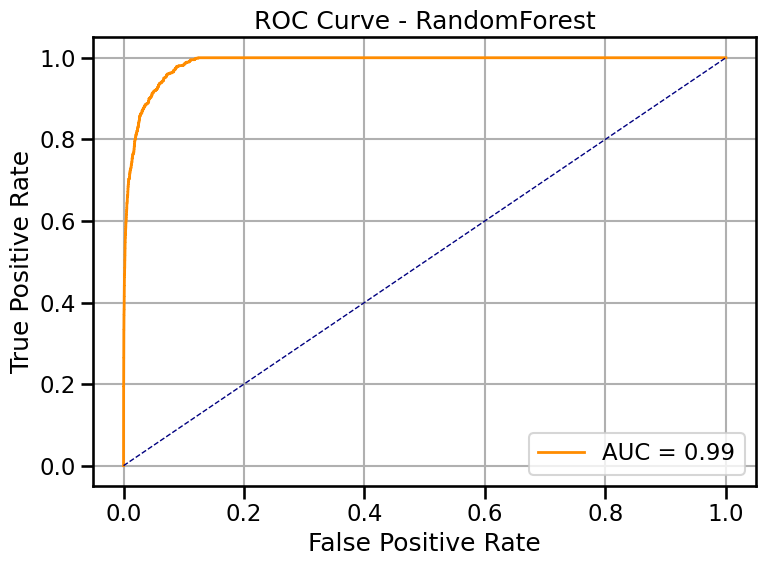

In [22]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for class 1 (positive class)
y_probs = best_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label="AUC = %0.2f" % roc_auc)
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RandomForest")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [23]:
import joblib
# Assuming your model is named 'rf' or similar
joblib.dump(best_rf, 'saved_model.pkl')

['saved_model.pkl']

In [24]:
joblib.dump(rf, 'saved_model2.pkl')

['saved_model2.pkl']